In [2]:
import numpy as np
import networkx as nx
import os
from scipy.linalg import sqrtm, logm
import matplotlib.pyplot as plt
from collections import defaultdict

from qiskit_aer import Aer
from qiskit import QuantumCircuit, ClassicalRegister, transpile
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

zero_state = np.array([[1,0],[0,0]], dtype=complex)
one_state = np.array([[0,0],[0,1]], dtype=complex)
phase_z = np.array([[1,0],[0,-1j]], dtype=complex)
hadamard = (1/np.sqrt(2)) * np.array([[1,1],[1,-1]], dtype=complex)
identity = np.eye(2, dtype=complex)
unitaries = [hadamard, hadamard @ phase_z , identity]

In [ ]:

service = QiskitRuntimeService()


In [3]:
backends = {}
backends["ideal"] = Aer.get_backend("qasm_simulator")
backends["ibm_fez"] = service.backend("ibm_fez")
backends["ibm_brisbane"] = service.backend("ibm_brisbane")

In [4]:
from datetime import datetime

# Get current date and time
now = datetime.now()

backend_name = "ibm_brisbane"
# Convert to string
date_string = now.strftime("%Y-%m-%d")

properties = backends[backend_name].properties().to_dict()
os.makedirs(f"./Data/{backend_name}/Calibration/", exist_ok=True)
np.save(f"./Data/{backend_name}/Calibration/{date_string}.npy", properties)

In [ ]:
def classical_shadows_circuits(circuit, unitary_ids, backend):
    """
    Input:
        circuit: Qiskit circuit that one wants to know the density matrix
        unitary_ids: Random basis to measure the circuit to recover the Classical Shadows information
        backend: Where the circuit will run (Important to transpile in terms of the backend layout) 
    Return: Circuit with the classical shadows basis.
    """
    num_shadow = len(unitary_ids)
    num_qubits = circuit.num_qubits
    qcs = []
    for shadow_i in range(num_shadow):
        qc_g = QuantumCircuit(num_qubits)
        for i in range(num_qubits):
            if unitary_ids[shadow_i, i] == 0:
                qc_g.h(i)
            elif unitary_ids[shadow_i, i] == 1:
                qc_g.sdg(i)
                qc_g.h(i) 
            elif unitary_ids[shadow_i, i] == 2:
                pass
            else:
                raise ValueError("This is not a valid pauli string")
        qc_g = transpile(qc_g, backend, optimization_level=0)
        qc = circuit.compose(qc_g, range(num_qubits))
        qc.add_register(ClassicalRegister(num_qubits))
        qc.measure(range(num_qubits), reversed(range(num_qubits)))
        qcs.append(qc)
        if not shadow_i % (num_shadow//10):
            print(f" Shadows: {shadow_i}")
    return qcs

def qaoa_maxcut(G, gammas, betas):
    p = len(gammas) 
    nodes = G.nodes()
    num_nodes =len(nodes)
    weights = [G[i][j]["weight"] for i,j in G.edges()]
    max_weight = max(weights)
    qc = QuantumCircuit(num_nodes)
    qc.h(nodes)
    for pi in range(p):
        for i, j in G.edges():
            qc.cx(i, j)
            qc.rz(2 * gammas[pi] * G[i][j]["weight"]/max_weight,j)
            qc.cx(i, j)
        qc.rx(-2 * betas[pi], nodes)
    return qc

def arn_circuits(qcs, n_shadow, backend, cases, max_circs=300):
    arn = []
    list_qc = np.concatenate((np.arange(0, n_shadow, max_circs),[n_shadow]))
    sampler = Sampler(mode=backend)
    for i in cases:
        arn.append(sampler.run(qcs[list_qc[i]:list_qc[i+1]], shots=1).job_id())
        print(f"------Completed {i+1} from {len(list_qc)-1}-----")
    return arn

def retrieved_info(arn, n_shadow):
    snapshots = []
    list_qc = np.concatenate((np.arange(0, n_shadow, 300),[n_shadow]))
    for i in range(len(list_qc)-1):
        jobs = service.job(job_id=arn[i]).result()
        dict_results = [getattr(jobs[i].data, [i for i in dir(jobs[i].data) if i[0] == "c"][0]).get_counts() for i in range(len(jobs))]
        snapshots += [list(i.keys())[0] for i in dict_results]
        # snapshots += [list(i.keys())[0] for i in provider.backend.retrieve_job(job_id=arn[i]).result().get_counts()]
        
        print(f"------Completed {i+1} from {len(list_qc)-1}-----")
    return snapshots

def snapshot_state(b_list, obs_list, list_qubits):
    num_qubits = len(b_list)
    if len(list_qubits) == 0:
        list_qubits = range(num_qubits)
    # computational basis state
    rho_snapshot = [1]
    for i in reversed(list_qubits):
        state = zero_state if b_list[i] == "0" else one_state
        U = unitaries[obs_list[i]] 
        local_rho = 3 * (U.conj().T @ state @ U) - identity # Eq. S44 classical shadows paper
        rho_snapshot = np.kron(rho_snapshot, local_rho)
    return rho_snapshot

def shadow_state_reconstruction(shadow, basis, list_qubits):
    num_snapshots = len(shadow)
    num_qubits = len(list_qubits)
    
    shadow_rho = np.zeros((2 ** num_qubits, 2 ** num_qubits), dtype=complex)
    for i in range(num_snapshots):
        shadow_rho += snapshot_state(shadow[i], basis[i], list_qubits)
    
    return shadow_rho / num_snapshots

def zecs(p):
    """
    Find the singular vector corresponding to the smallest singular value 
    (which can approximate the zero energy coherent state, ZEC).

    Parameters:
    p (numpy.ndarray): A density matrix or any square matrix.

    Returns:
    numpy.ndarray: The singular vector corresponding to the smallest singular value.
    """
    
    # Step 1: Perform Singular Value Decomposition (SVD) of the input matrix p.
    # np.linalg.svd returns three matrices: U and singular values (S).
    U, S, _ = np.linalg.svd(p, hermitian=True)
    
    # Step 2: Extract the right-singular vector (fist column of U) corresponding to the largest singular value.
    # This state vector contains the largest overlap with the ideal state vector that described the given circuit.
    best_sv = U[:,0].reshape(-1, 1)  # Reshaping into a column vector.

    # Step 3: Return the singular vector corresponding to the largest singular value.
    return best_sv

def fidelity(rho_ideal, rho_real):
    """
    Calculate the fidelity between two quantum states represented by density matrices.
    
    Fidelity is a measure of how close two quantum states are, where a value of 1 means 
    the states are identical, and a value of 0 means they are orthogonal (completely different).

    Parameters:
    rho_ideal (numpy.ndarray): The ideal density matrix (target quantum state).
    rho_real (numpy.ndarray): The actual density matrix (quantum state to compare to the ideal).

    Returns:
    float: The fidelity between rho_ideal and rho_real, a value between 0 and 1.
    """
    
    # Step 1: Compute the matrix square root of the real density matrix (rho_real)
    # The matrix square root operation finds a matrix such that s_rho_real * s_rho_real = rho_real
    s_rho_real = sqrtm(rho_real)

    # Step 2: Compute the intermediate matrix: s_rho_real * rho_ideal * s_rho_real
    # This is part of the Uhlmann's fidelity formula: sqrt(sqrt(rho_real) * rho_ideal * sqrt(rho_real))
    intermediate_matrix = s_rho_real @ rho_ideal @ s_rho_real

    # Step 3: Take the matrix square root of the intermediate result to continue the fidelity calculation
    # sqrtm computes the square root of the matrix
    sqrt_intermediate_matrix = sqrtm(intermediate_matrix)

    # Step 4: The fidelity is the squared trace of the resulting matrix.
    # .trace() computes the sum of the diagonal elements of the matrix.
    # .real ensures we only take the real part of the trace (since small imaginary values might arise from numerical errors).
    fidelity_value = (sqrt_intermediate_matrix.trace().real) ** 2

    # Step 5: Return the fidelity value (a number between 0 and 1)
    return fidelity_value

def entropy(p):
    """
    Calculate the von Neumann entropy of a density matrix.

    The von Neumann entropy is a measure of the quantum state's uncertainty or mixedness.
    It is given by the formula: S(p) = -Tr(p * log(p)), where 'log' is the matrix logarithm,
    and Tr() is the trace operation (sum of diagonal elements).

    Parameters:
    p (numpy.ndarray): The density matrix, a square matrix that represents the quantum state.

    Returns:
    float: The von Neumann entropy of the quantum state, a non-negative real number.
    """
    
    # Step 1: Compute the matrix logarithm of the density matrix p.
    # logm(p) computes the logarithm of a matrix, which is needed in the von Neumann entropy formula.
    log_p = logm(p)

    # Step 2: Compute the product of the density matrix p and its logarithm.
    # This gives us p * log(p), which will be used to compute the entropy.
    entropy_matrix = p @ log_p

    # Step 3: Compute the trace of the product matrix.
    # The trace is the sum of the diagonal elements of the matrix.
    # .real ensures that we only take the real part of the trace, to avoid numerical artifacts.
    entropy_value = (-entropy_matrix).trace().real

    # Step 4: Return the von Neumann entropy.
    return entropy_value

def trace_distance(p1, p2):
    """
    Calculate the trace distance between two density matrices.
    
    The trace distance is a measure of the distinguishability between two quantum states.
    It is defined as D(p1, p2) = 0.5 * Tr(|p1 - p2|), where |A| represents the square root
    of the positive semidefinite matrix A^† A.
    
    Args:
        p1 (numpy.ndarray): The first density matrix.
        p2 (numpy.ndarray): The second density matrix.
    
    Returns:
        float: The trace distance between p1 and p2.
    """
    
    # Step 1: Compute the difference between the two density matrices
    R = p1 - p2
    
    # Step 2: Compute the square root of the matrix R^† R (R conjugate transpose times R)
    # This is equivalent to taking the absolute value of the operator.
    abs_R = sqrtm(R.conj().T @ R)
    
    # Step 3: Compute the trace of the absolute value matrix
    trace_abs_R = np.trace(abs_R).real  # Take only the real part
    
    # Step 4: Return half of the trace as per the definition of trace distance
    return 0.5 * trace_abs_R

def shortest_path(nq_chain, G_entropy):
    num_qubits = G_entropy.number_of_nodes()
    paths = []
    S_total = []
    for i in range(num_qubits):
        for j in range(i+1, num_qubits):
            sp = nx.shortest_path(G_entropy, source=i, target=j)
            if len(sp) == nq_chain:
                Sab = 0
                for k in range(nq_chain-1):
                    Sab += G_entropy[sp[k]][sp[k+1]]["weight"]
                paths.append(sp)
                S_total.append(Sab)
    return np.array(S_total), paths

In [105]:
np.random.seed(1)

backend_name = "ibm_brisbane"
couplings = [] 
for ij in list(backends[backend_name].coupling_map):
    if ij not in couplings and (ij[1],ij[0]) not in couplings:
        couplings.append(ij) 
layers = [[], [], []]
for ij in couplings:
    flag = False
    while not flag:
        choice = np.random.choice([0,1,2])
        flag = ij[0] not in np.unique(layers[choice]) and ij[1] not in np.unique(layers[choice])
        if flag:
            layers[choice].append(list(ij))
sorted_gates = layers

In [7]:
# QAOA 2-qubit problem
G = nx.Graph()
G.add_nodes_from(range(2))
G.add_weighted_edges_from([[0, 1, 0.5]])  

In [ ]:
results = {}
backend_name = "ibm_brisbane"
n_qubits = backends[backend_name].num_qubits
results["shots"] = 6000
results["layers"] = sorted_gates
p = 10 # Number of QAOA layers
delta = 0.6
layer = 0 # There are 3 layers in Hevy-Hex topology 


qc = QuantumCircuit(n_qubits)
params = []
betas = list(np.arange(1, p+1)[::-1] * delta / p)
gammas = list(np.arange(1, p+1) * delta / p)
qc_qaoa = qaoa_maxcut(G, gammas, betas)
for i in results["layers"][layer]:
    qc = qc.compose(qc_qaoa, i)
results["pideal"] = np.array(DensityMatrix(qc_qaoa))
qc = transpile(qc, backends[backend_name], optimization_level=1)
results["depth"] = qc.depth()
results["operations"] = qc.count_ops()    
results["random_unitaries"] = np.random.randint(0, 3, size=(results["shots"], n_qubits))

qcs = classical_shadows_circuits(qc, results["random_unitaries"], backends[backend_name])

 Shadows: 0
 Shadows: 600
 Shadows: 1200
 Shadows: 1800
 Shadows: 2400
 Shadows: 3000
 Shadows: 3600
 Shadows: 4200
 Shadows: 4800
 Shadows: 5400


In [ ]:
os.makedirs(f"./Data/{backend_name}/", exist_ok=True)
cases = np.array(list(range(20)))

arn = arn_circuits(qcs, results["shots"], backends[backend_name], cases=cases)
results["arn"] = arn
np.save(f"./Data/{backend_name}/shadows_{layer}.npy", results)

------Completed 1 from 20-----
------Completed 2 from 20-----
------Completed 3 from 20-----
------Completed 4 from 20-----
------Completed 5 from 20-----
------Completed 6 from 20-----
------Completed 7 from 20-----
------Completed 8 from 20-----
------Completed 9 from 20-----
------Completed 10 from 20-----
------Completed 11 from 20-----
------Completed 12 from 20-----
------Completed 13 from 20-----
------Completed 14 from 20-----
------Completed 15 from 20-----
------Completed 16 from 20-----
------Completed 17 from 20-----
------Completed 18 from 20-----
------Completed 19 from 20-----
------Completed 20 from 20-----


In [34]:
layer = 2
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
results["snapshots"] = retrieved_info(results["arn"], results["shots"])
np.save(f"./Data/{backend_name}/shadows_{layer}.npy", results)

------Completed 1 from 20-----
------Completed 2 from 20-----
------Completed 3 from 20-----
------Completed 4 from 20-----
------Completed 5 from 20-----
------Completed 6 from 20-----
------Completed 7 from 20-----
------Completed 8 from 20-----
------Completed 9 from 20-----
------Completed 10 from 20-----
------Completed 11 from 20-----
------Completed 12 from 20-----
------Completed 13 from 20-----
------Completed 14 from 20-----
------Completed 15 from 20-----
------Completed 16 from 20-----
------Completed 17 from 20-----
------Completed 18 from 20-----
------Completed 19 from 20-----
------Completed 20 from 20-----


In [116]:
layer  = 1
backend_name = "ibm_brisbane"
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()


In [45]:
nq = 127
distance_device = np.load(f"./Data/distace_{nq}_HE.npy",allow_pickle=True)

distance = defaultdict(list)
for i in range(nq):
    for j in range(nq):
        if distance_device[i,j] == 1:
            distance[i].append(j)


In [46]:
layer_used = results["layers"][layer]
qubits_involved = np.unique(layer_used)
list_3q = []
list_4q = []
for qubits in layer_used:
    for qj in distance[qubits[0]]:
        if qj not in qubits_involved:
            list_3q.append(qubits + [qj])
        elif qj != qubits[1]:
            list_4q.append([qbts for qbts in layer_used if qj in qbts][0] + qubits)
    for qj in distance[qubits[1]]:
        if qj not in qubits_involved:
            list_3q.append(qubits + [qj])

# Postprocessing results

In [47]:
# Initialize an empty dictionary for storing postprocessing results
results["postprocessing"] = {}

# Create an array of 10 evenly spaced snapshot points starting at 100 up to the number of shots.
# These will be used to track progress and performance at different numbers of measurement shots.
results["postprocessing"]["snapshots"] = np.linspace(100, results["shots"], 10, dtype=int)
results["list_3q"] = list_3q
results["list_4q"] = list_4q
results["pideal_3q"] = np.kron(np.array([[1, 0], [0, 0]]), np.array(results["pideal"]))
results["pideal_4q"] = np.kron(np.array(results["pideal"]), np.array(results["pideal"]))
# Loop over all quantum systems, which are stored in lists of 2-qubit, 3-qubit, and 4-qubit systems.
# These systems will undergo further post-processing.
for system in results["layers"][layer] + list_3q + list_4q:
    system = tuple(system)  # Convert system to a tuple to ensure immutability
    print(f"------------      System      {system}    ----------------")

    # Initialize dictionaries to store results for Classical Shadows (CS) and Zero-Entropy Classical Shadows (ZECS)
    # for fidelity ("F") and trace distance ("D").
    results["postprocessing"][system] = {}
    results["postprocessing"][system]["CS"] = {"F":[], "D":[]}  # For Classical Shadows
    results["postprocessing"][system]["ZECS"] = {"F":[], "D":[]}  # For Zero-Entropy Classical Shadows

    # Generate the ideal (ground truth) state based on the system size
    if len(system) == 2:
        p0 = results["pideal"]
    # For 3-qubit systems, apply a Kronecker product to a basis state and a two-qubit ideal state
    if len(system) == 3:
        p0 = results["pideal_3q"]
    # For 4-qubit systems, apply a Kronecker product of two 2-qubit ideal states
    elif len(system) == 4:
        p0 = results["pideal_4q"]
    # Store the ideal state for comparison in the later post-processing
    # Iterate over the snapshot points to reconstruct the quantum state after a certain number of shots
    for nn, i in enumerate(results["postprocessing"]["snapshots"]):
        # Perform classical shadow state reconstruction using a subset of the available shots
        rho_csi = shadow_state_reconstruction(results["snapshots"][:i], results["random_unitaries"][:i], list_qubits=system)

        # Compute the Zero-Entropy Classical Shadow State (ZECS)
        sv_zecsi = zecs(rho_csi)
        
        # Create the density matrix for the ZECS by taking the outer product of the state vector with itself
        rho_zecsi = sv_zecsi @ sv_zecsi.T.conj()

        # Evaluate both the classical shadow (CS) state and the ZECS state for two properties: 
        # fidelity ("F") and trace distance ("D").
        for method, p in {"CS": rho_csi, "ZECS": rho_zecsi}.items():
            for prop, func in {"F": fidelity, "D": trace_distance}.items():
                results["postprocessing"][system][method][prop].append(func(p0, p))

        # Print the number of shots processed at this point in the loop
        print(f'Number of shots completed {results["postprocessing"]["snapshots"][nn]}')

    # Store the final reconstructed states (density matrices) for both CS and ZECS in the results
    results["postprocessing"][system]["CS"]["p"] = rho_csi
    results["postprocessing"][system]["ZECS"]["p"] = rho_zecsi

    # If the system has more than two qubits (3 or 4 qubits), compute and store the entanglement entropy
    # of the ZECS density matrix with respect to subsystem 1. Note that the entanglement entropy of subsystem 2 will be the same of subsystem 1 by construction
    if len(system) > 2:
        results["postprocessing"][system]["ZECS"]["Sab"] = entropy(partial_trace(results["postprocessing"][system]["ZECS"]["p"], [0, 1]))

# Save the postprocessing results to a .npy file for further analysis, using the backend name and repetitions in the filename
np.save(f"./Data/{backend_name}/shadows_{layer}.npy", results)


------------      System      (4, 15)    ----------------
Number of shots completed 100
Number of shots completed 755
Number of shots completed 1411
Number of shots completed 2066
Number of shots completed 2722
Number of shots completed 3377
Number of shots completed 4033
Number of shots completed 4688
Number of shots completed 5344
Number of shots completed 6000
------------      System      (6, 5)    ----------------
Number of shots completed 100
Number of shots completed 755
Number of shots completed 1411
Number of shots completed 2066
Number of shots completed 2722
Number of shots completed 3377
Number of shots completed 4033
Number of shots completed 4688
Number of shots completed 5344
Number of shots completed 6000
------------      System      (7, 8)    ----------------
Number of shots completed 100
Number of shots completed 755
Number of shots completed 1411
Number of shots completed 2066
Number of shots completed 2722
Number of shots completed 3377
Number of shots completed 40

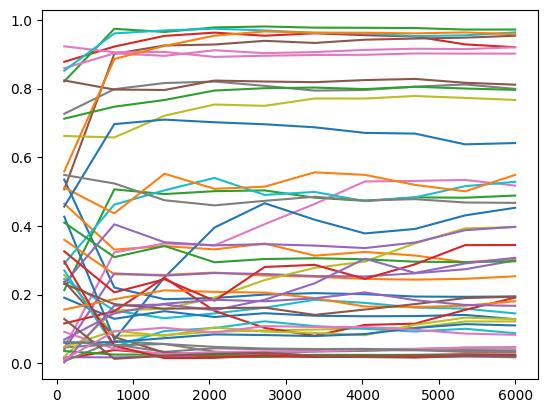

In [121]:
for system in results["layers"][layer]:
    plt.plot(results["postprocessing"]["snapshots"], results["postprocessing"][tuple(system)]["ZECS"]["F"])
    # plt.plot(results["postprocessing"][tuple(system)]["CS"]["F"], linestyle="--")
# plt.ylim(0.9,1)

# Entanglement entropy of each subsytem with the other subsytems

In [ ]:
nq = 127
layer = 2
backend_name = "ibm_brisbane"
results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()

list_1q = [[i] for i in range(nq) if i not in np.unique(results["layers"][layer])]
systems_involved = results["layers"][layer]  + list_1q
results["entropy_systems"] = systems_involved

num_systems = len(systems_involved)
Sab = np.zeros((num_systems, num_systems))
# Loop over all quantum systems, which are stored in lists of 2-qubit, 3-qubit, and 4-qubit systems.
# These systems will undergo further post-processing.
for i in range(num_systems):
    print(f"System: {i+1} out of {num_systems}")
    for j in range(i+1, num_systems):
        system = tuple(systems_involved[i] + systems_involved[j])

        rho_csi = shadow_state_reconstruction(results["snapshots"], results["random_unitaries"], list_qubits=system)

        # Compute the Zero-Entropy Classical Shadow State (ZECS)
        sv_zecsi = zecs(rho_csi)
        
        # Create the density matrix for the ZECS by taking the outer product of the state vector with itself
        rho_zecsi = sv_zecsi @ sv_zecsi.T.conj()
        if len(system) > 2:
            Sab[i,j] = Sab[j,i] = entropy(partial_trace(rho_zecsi, [0, 1]))
        else:
            Sab[i,j] = Sab[j,i] = entropy(partial_trace(rho_zecsi, [0]))
results["Sab"] = Sab
# Save the postprocessing results to a .npy file for further analysis, using the backend name and repetitions in the filename
np.save(f"./Data/{backend_name}/shadows_{layer}.npy", results)


System: 1 out of 79
System: 2 out of 79
System: 3 out of 79
System: 4 out of 79
System: 5 out of 79
System: 6 out of 79
System: 7 out of 79
System: 8 out of 79
System: 9 out of 79
System: 10 out of 79
System: 11 out of 79
System: 12 out of 79
System: 13 out of 79
System: 14 out of 79
System: 15 out of 79
System: 16 out of 79
System: 17 out of 79
System: 18 out of 79
System: 19 out of 79
System: 20 out of 79
System: 21 out of 79
System: 22 out of 79
System: 23 out of 79
System: 24 out of 79
System: 25 out of 79
System: 26 out of 79
System: 27 out of 79
System: 28 out of 79
System: 29 out of 79
System: 30 out of 79
System: 31 out of 79
System: 32 out of 79
System: 33 out of 79
System: 34 out of 79
System: 35 out of 79
System: 36 out of 79
System: 37 out of 79
System: 38 out of 79
System: 39 out of 79
System: 40 out of 79
System: 41 out of 79
System: 42 out of 79
System: 43 out of 79
System: 44 out of 79
System: 45 out of 79
System: 46 out of 79
System: 47 out of 79
System: 48 out of 79
S

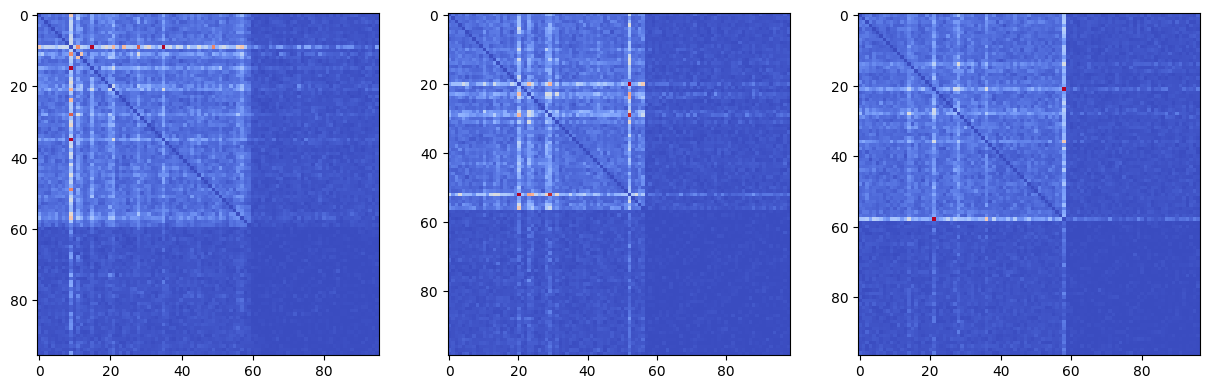

In [3]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
for layer in range(3):
    backend_name = "ibm_fez"
    results = np.load(f"./Data/{backend_name}/shadows_{layer}.npy", allow_pickle=True).item()
    Sab = results["Sab"]
    
    ax1 = ax[layer].imshow(Sab, cmap="coolwarm")
    # fig.colorbar(ax1)


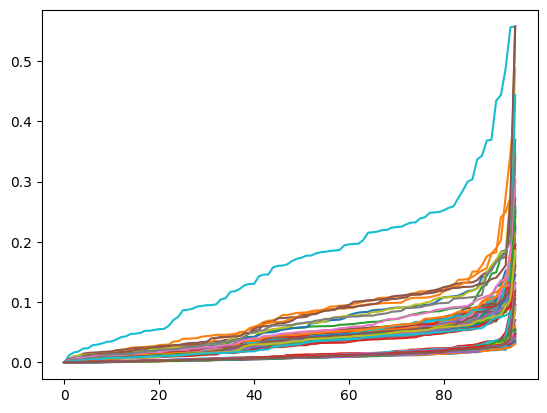

In [153]:
for i in range(96):
    plt.plot(sorted(results["Sab"][i]))